In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import strategies

plt.rcParams["figure.figsize"] = (10, 4)

prices = pd.read_parquet(DATA / "processed" / "precos.parquet")
cdi = pd.read_parquet(DATA / "processed" / "cdi.parquet")["cdi"]
rets = prices.pct_change(fill_method=None).fillna(0.0)

In [3]:
td = pd.read_csv(DATA / "raw" / "tesouro_precos_taxas.csv", sep=";", decimal=",", encoding="latin-1")
td.columns = [c.strip() for c in td.columns]
td["Tipo Titulo"].unique()

<ArrowStringArray>
[                         'Tesouro Selic',
                      'Tesouro Prefixado',
     'Tesouro IPCA+ com Juros Semestrais',
                          'Tesouro IPCA+',
     'Tesouro IGPM+ com Juros Semestrais',
 'Tesouro Prefixado com Juros Semestrais',
     'Tesouro Renda+ Aposentadoria Extra',
                         'Tesouro Educa+']
Length: 8, dtype: str

<Axes: title={'center': 'Taxa pré ~1 ano (Tesouro Direto)'}, xlabel='base'>

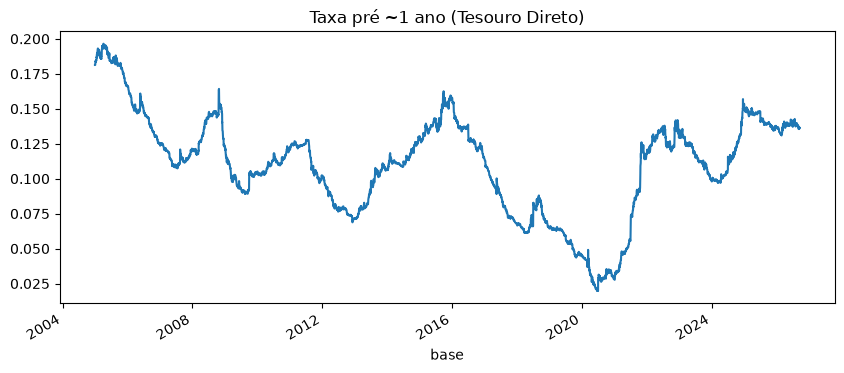

In [4]:
pre = td[td["Tipo Titulo"] == "Tesouro Prefixado"].copy()
pre["base"] = pd.to_datetime(pre["Data Base"], dayfirst=True)
pre["venc"] = pd.to_datetime(pre["Data Vencimento"], dayfirst=True)
pre["prazo_dias"] = (pre["venc"] - pre["base"]).dt.days
pre = pre[(pre["prazo_dias"] > 180) &  (pre["prazo_dias"] < 730)]

idx = (pre["prazo_dias"] - 365).abs().groupby(pre["base"]).idxmin()
y_1y = (pre.loc[idx].set_index("base")["Taxa Compra Manha"] / 100).sort_index()
y_1y.name = "y_1y"
y_1y.plot(title="Taxa pré ~1 ano (Tesouro Direto)")

<Axes: xlabel='Date'>

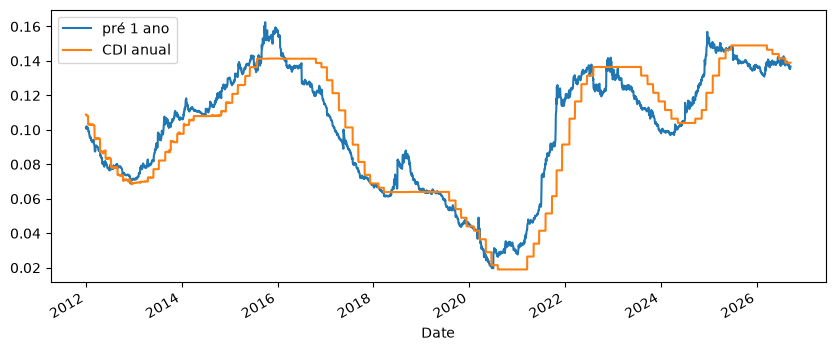

In [5]:
cdi_anual = ((1 + cdi) ** 252 - 1).where(cdi > 0).ffill()
pd.DataFrame({"pré 1 ano": y_1y.reindex(cdi.index).ffill(), "CDI anual": cdi_anual}).plot()

<Axes: title={'center': 'Carry com curva REAL vc CDI'}, xlabel='Date'>

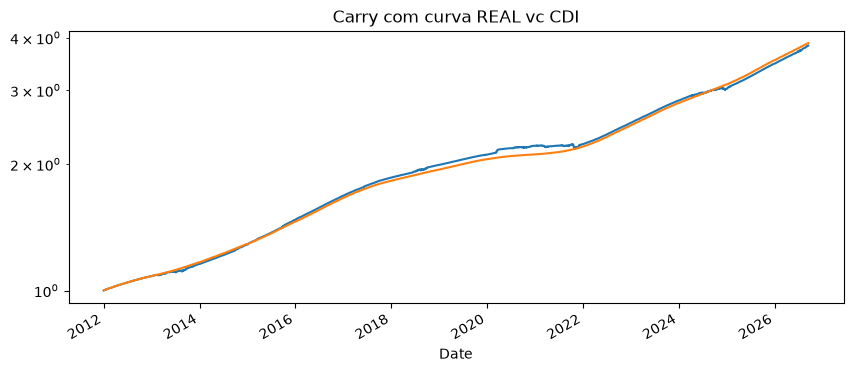

In [8]:
y_1y.to_frame().to_parquet(DATA / "processed" / "curva_pre_1y.parquet")
r_carry = strategies.carry_returns(y_1y, cdi)
(1 + r_carry).cumprod().plot(logy=True, title="Carry com curva REAL vc CDI")
(1 + cdi).cumprod().plot()

In [9]:
w = strategies.momentum(prices)
gross = (w * rets).sum(axis=1)


In [10]:
cost_bps = 10
turnover = w.diff().abs().sum(axis=1)
turnover.iloc[0] = w.iloc[0].abs().sum()
cost = turnover * cost_bps / 1e4
print(f"custo médio anual: {cost.mean() * 252:.2%}")

custo médio anual: 0.53%


In [11]:
exposure = w.abs().sum(axis=1)
cash = (1 - exposure).clip(lower=0) * cdi

<Axes: title={'center': 'Momentum: bruto vs líquido'}, xlabel='Date'>

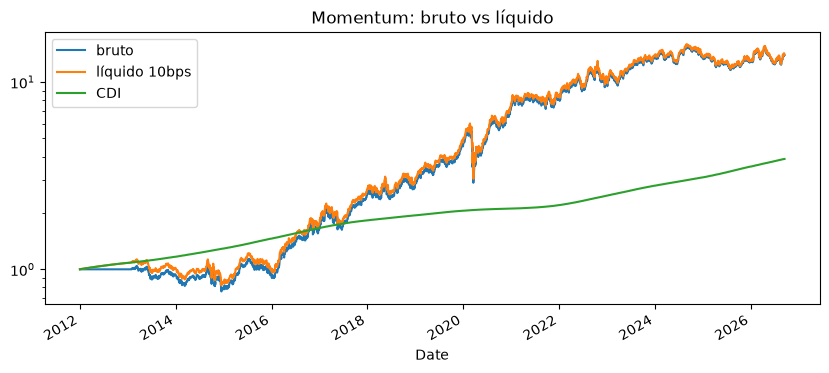

In [12]:
net = gross - cost + cash
pd.DataFrame({"bruto": (1 + gross).cumprod(), "líquido 10bps": (1 + net).cumprod(),
              "CDI": (1 + cdi).cumprod()}).plot(logy=True, title="Momentum: bruto vs líquido")

In [13]:
from moq import backtest

res = backtest.run(strategies.momentum(prices), prices, cdi, cost_bps=10)
np.allclose(res.ret, net)

True

In [20]:
from moq import metrics

estrategias = {
    "momentum": strategies.momentum(prices),
    "reversao": strategies.mean_reversion(prices),
    "pares":    strategies.pairs(prices, a="ITUB4", b="BBDC4"),
}

linhas = []
for nome, w in estrategias.items():
    for bps in (0, 10, 30):
        r = backtest.run(w, prices, cdi, cost_bps=bps).ret
        linhas.append({"estrategia": nome, "custo_bps": bps, **metrics.summary(r, cdi)})
tabela = pd.DataFrame(linhas).pivot(index="estrategia", columns="custo_bps", values="sharpe")
tabela.round(2)


AttributeError: module 'moq.metrics' has no attribute 'summary'

## Overfitting: de quantas tentativas esse Sharpe é o melhor?

A tabela acima tem um número por estratégia, mas cada um deles saiu de uma escolha de parâmetros — e escolher parâmetros olhando o resultado é o jeito mais fácil de produzir um backtest bonito que não significa nada.

Para medir o tamanho do problema, monto um mercado onde **não existe nada para capturar**: vinte ativos em passeio aleatório puro, sem tendência, sem autocorrelação, sem fator comum. Nesse mundo o momentum não tem como funcionar, então todo Sharpe positivo que aparecer é sorte da amostra. Aí varro a grade de parâmetros inteira e olho o melhor.

In [ ]:
rng = np.random.default_rng(42)
fake = pd.DataFrame(100 * np.exp(np.cumsum(rng.normal(0, 0.015, (2500, 20)), axis=0)),
                    index=pd.bdate_range("2015-01-01", periods=2500),
                    columns=[f"F{i}" for i in range(20)])
cdi0 = pd.Series(0.0, index=fake.index)

resultados = []
for lb in (63, 126, 189, 252, 378):
    for sk in (1, 5, 10, 21):          # momentum exige lookback > skip > 0: skip=0 levanta ValueError
        for top in (0.1, 0.2, 0.3):
            if not (lb > sk > 0):
                continue
            w = strategies.momentum(fake, lookback=lb, skip=sk, top=top)
            r = backtest.run(w, fake, cdi0, cost_bps=10).ret
            resultados.append({"lookback": lb, "skip": sk, "top": top, "sharpe": metrics.sharpe(r, cdi0)})

res = pd.DataFrame(resultados).sort_values("sharpe", ascending=False)
print(f"{len(res)} combinações testadas em dados SEM NENHUM SINAL")
print(f"melhor Sharpe: {res['sharpe'].iloc[0]:.2f}   mediana: {res['sharpe'].median():.2f}   pior: {res['sharpe'].iloc[-1]:.2f}")
res.head()

**Em dados aleatórios, o melhor de 60 parâmetros teve Sharpe 0,73.**

A mediana das 60 combinações foi 0,15 e a pior, −0,44. Ou seja: a dispersão entre a melhor e a pior configuração — quase 1,2 de Sharpe — é **inteiramente ruído**, porque por construção não havia nada para nenhuma delas encontrar. Quem rodasse essa grade, guardasse `lookback=63, skip=1, top=0.1` e mostrasse só essa linha teria um backtest aparentemente decente em cima de números que eu mesma sorteei.

Isso muda como ler a tabela da seção anterior. O momentum na base real deu Sharpe 0,48 com 10 bps de custo — **abaixo do melhor que o ruído puro produziu aqui**. A comparação não é rigorosa (períodos, número de ativos e volatilidades diferentes), mas dá a escala: um Sharpe dessa ordem, escolhido depois de varrer parâmetros, não se distingue de sorte.

A pergunta que fica para qualquer backtest, meu ou dos outros: **de quantas tentativas ele é o melhor?** Se a resposta não aparece junto com o número, o número está incompleto. E é por isso que os parâmetros deste projeto são os do roteiro, fixados antes de olhar o resultado — a hora de fazer busca de parâmetros é com separação entre treino e teste, não com a amostra inteira na mão.

## Walk-forward: um fold à mão

A defesa contra o que a seção anterior mostrou: escolher os parâmetros numa janela (**treino**) e medir o resultado na janela seguinte (**teste**), que os parâmetros nunca viram. Se o Sharpe do treino só existia porque eu varri a grade, ele não sobrevive ao teste.

Um fold só, na mão, antes de escrever a função — treina em 2013–2015, testa em 2016.

Duas regras que o fold precisa respeitar:

1. **Warm-up.** Se a estratégia receber só 2016, ela passa o ano inteiro sem sinal: a janela de `lookback` dias nunca enche. Então ela recebe o passado para **ler**, e o `.loc[teste.index]` garante que só 2016 entra na **conta**. Ler o passado não é look-ahead; avaliar o passado seria.
2. **Treino e teste não se sobrepõem**, nem por um dia: `treino.index.max() < teste.index.min()`.

In [ ]:
# atenção: prices["2016"] procura uma COLUNA chamada "2016" e levanta KeyError.
# fatiar linha por string só funciona com slice (prices["2013":"2015"]) ou com .loc
treino = prices.loc["2013":"2015"]
teste = prices.loc["2016"]
grade = [{"lookback": lb, "top": t} for lb in (126, 252) for t in (0.2, 0.3)]

# 1) escolhe o melhor NO TREINO
scores = {}
for p in grade:
    w = strategies.momentum(treino, **p)
    scores[str(p)] = metrics.sharpe(backtest.run(w, treino, cdi, 10).ret, cdi)

melhor = grade[int(np.nanargmax(list(scores.values())))]  # nanargmax: um NaN na grade não ganha a escolha
for k, v in scores.items():
    print(f"   {k}: {v:+.2f}")
print("escolhido no treino:", melhor, "| sharpe treino:", round(max(scores.values()), 2))

# 2) aplica NO TESTE, com warm-up: momentum precisa de lookback + skip = 252 + 21 = 273 pregões
#    ANTES do primeiro dia de 2016, e um ano só (2015 tem 246) não enche a janela
teste_com_warmup = prices.loc["2014":"2016"]
w_teste = strategies.momentum(teste_com_warmup, **melhor).loc[teste.index]
r_teste = backtest.run(w_teste, teste, cdi, 10).ret
print("sharpe teste:", round(metrics.sharpe(r_teste, cdi), 2))

# as duas checagens do fold
print("sem sobreposição:", treino.index.max() < teste.index.min(),
      f"({treino.index.max().date()} < {teste.index.min().date()})")
print("dias de 2016 com posição:", int((w_teste.abs().sum(axis=1) > 0).sum()), "de", len(teste))

In [ ]:
# quanto custa errar o tamanho do warm-up
for ini in ("2016", "2015", "2014", "2013"):
    w = strategies.momentum(prices.loc[ini:"2016"], **melhor).loc[teste.index]
    r = backtest.run(w, teste, cdi, 10).ret
    dias = int((w.abs().sum(axis=1) > 0).sum())
    print(f"warm-up desde {ini}: {dias:3d}/{len(teste)} dias com posição | sharpe do teste {metrics.sharpe(r, cdi):5.2f}")

**O que saiu.** No treino as quatro combinações deram Sharpe **negativo** (de −0,69 a −0,15) e a "vencedora" foi `lookback=252, top=0.3`, com **−0,15** — a menos ruim. No teste, essa mesma configuração fez **+1,50** em 2016.

**O teste saiu melhor que o treino, e isso não é vitória.** O esperado é o contrário, e a explicação está no regime, não nos parâmetros: o universo equiponderado caiu **25%** em 2013–2015 e subiu **59%** em 2016, com o CDI em 13,9%. Momentum long-only perde em mercado que cai e ganha em mercado que sobe; o fold mediu o ano, não a qualidade da escolha. Se eu tivesse invertido as janelas, a conclusão viraria ao contrário com os mesmos parâmetros.

É por isso que **um fold não é evidência**. Ele serve para acertar a mecânica — separação de janelas, warm-up, nenhuma sobreposição — e o número que sai dele não decide nada. A pergunta "esses parâmetros generalizam?" só começa a ter resposta com a sequência inteira de folds, olhando a distribuição dos Sharpes de teste, não o melhor nem o último.

**Sobre o warm-up:** dar só 2015 para a estratégia ler deixa **229 dos 249 pregões** de 2016 sem posição, porque `lookback + skip` são 273 pregões e 2015 tem 246. As três primeiras semanas do teste ficam zeradas e o Sharpe cai para 1,19 — não por causa do mercado, por falta de janela. O warm-up tem que ser dimensionado pelo parâmetro (`lookback + skip`), nunca por "um ano". Daqui em diante ele entra como conta, não como chute.

Duas checagens que passaram: o Sharpe de treino é de fato o máximo das quatro combinações, e `treino.index.max() < teste.index.min()` é `True` (30/12/2015 < 04/01/2016).

Um detalhe que conferi e não deu problema: o `backtest.run` cobra o custo de entrada no primeiro dia da janela (`to.iloc[0] = |w.iloc[0]|`), o que poderia cobrar duas vezes por uma posição que veio de 2015. Aqui o turnover do primeiro dia é zero, então não houve cobrança indevida — mas em folds cujo primeiro dia já entra posicionado, esse custo aparece e não deveria.

## A função `walk_forward`: todos os folds

O fold à mão virou `backtest.walk_forward`: para cada ano de teste, treina nos `train_years` anteriores, escolhe o melhor parâmetro da grade **no treino** e aplica **no teste**. Devolve a série de retornos fora da amostra (os anos de teste emendados) e a lista de `Fold`, com o que foi escolhido e os dois Sharpes.

As grades são fixadas aqui e **não mudam depois** — mudar a grade olhando o resultado é o Passo 4 de novo, com passos extras.

O `warmup` é o único número que não copiei do roteiro, e é por causa do que a seção anterior mostrou: ele tem que cobrir a maior janela da grade, medida em pregões.

| estratégia | maior janela | warm-up |
|---|---|---|
| momentum | `lookback` 252 + `skip` 21 = 273 | **300** |
| reversão | `short` 10 + `long` 60 = 70 | **70** |
| pares | z-score precisa de 2 × `window` = 504 | **505** |

Em pares a diferença é grande: com os 260 do roteiro, só **28%** dos dias fora da amostra têm posição, contra **49%** com 505 — o resto do tempo a estratégia estava sem z-score, não sem oportunidade.

In [ ]:
GRADE_MOM = {"lookback": [126, 252], "top": [0.2, 0.3]}
GRADE_REV = {"short": [5, 10], "threshold": [1.5, 2.0]}
GRADE_PAR = {"entry": [1.5, 2.0], "window": [126, 252]}

oos_mom, folds_mom = backtest.walk_forward(strategies.momentum, prices, cdi, GRADE_MOM,
                                           train_years=3, test_years=1, cost_bps=10, warmup=300)
oos_rev, folds_rev = backtest.walk_forward(strategies.mean_reversion, prices, cdi, GRADE_REV, warmup=70)
oos_par, folds_par = backtest.walk_forward(lambda p, **k: strategies.pairs(p, a="ITUB4", b="BBDC4", **k),
                                           prices, cdi, GRADE_PAR, warmup=505)


def tabela_folds(folds):
    t = pd.DataFrame([{"teste": f.test_start.year, "params": f.chosen,
                       "sharpe_treino": round(f.train_sharpe, 2),
                       "sharpe_teste": round(f.test_sharpe, 2)} for f in folds])
    print(f"treino médio {t.sharpe_treino.mean():+.2f} | teste médio {t.sharpe_teste.mean():+.2f} | "
          f"teste < treino em {(t.sharpe_teste < t.sharpe_treino).sum()}/{len(t)} folds")
    return t


tabela_folds(folds_mom)

In [ ]:
tabela_folds(folds_rev)

In [ ]:
tabela_folds(folds_par)

**O que as três tabelas dizem.**

O Sharpe cai do treino para o teste em todas as estratégias, que é o resultado esperado e a razão de o Passo 4 existir: momentum **+0,48 → +0,25**, reversão **−0,10 → −0,92**, pares **−0,30 → −0,80** (médias dos 12 folds). A queda aparece em 8, 10 e 9 dos 12 folds, respectivamente.

**Os parâmetros escolhidos não estabilizam** — e isso é o achado mais informativo daqui. No momentum, o treino pediu `lookback=252` em 7 folds e `126` em 5; `top=0.2` em 7 e `0.3` em 5. É quase cara ou coroa. Se a vantagem de um parâmetro fosse real, ele venceria de forma consistente ano após ano; alternar assim diz que o treino está rankeando ruído, exatamente como nos dados sorteados da seção anterior.

Nenhum fold tem Sharpe de treino absurdo (o maior é +1,34, em 2020), então não há sinal de vazamento de dado — o problema é falta de sinal, não look-ahead.

Dois detalhes para não tropeçar depois: o fold de 2025 em pares tem `sharpe_teste = NaN` porque a estratégia passou o ano inteiro **fora do mercado** — com tudo em caixa, o retorno é exatamente o CDI, o excesso é zero e o desvio também, então o Sharpe não existe (não é zero). E o primeiro fold, 2015, é o pior de todos em momentum e pares: treinado em 2012–2014, testado no fundo da recessão.

## A tabela final e o que vai para a Fase 6

Agora os quatro retornos fora da amostra lado a lado. O carry não entra no `walk_forward` porque não tem grade nesta versão (`window` e `k` ficaram no padrão) — como nada nele foi escolhido olhando resultado, a série inteira já é honesta nesse sentido; só recorto no mesmo período dos outros.

In [ ]:
periodo = oos_mom.index
R_oos = pd.DataFrame({"momentum": oos_mom, "reversao": oos_rev, "pares": oos_par,
                      "carry": r_carry.reindex(periodo)}).dropna()
cdi_oos = cdi.reindex(R_oos.index)

resumo = pd.DataFrame({
    nome: {"sharpe": metrics.sharpe(r, cdi_oos),
           "ret_anual": (1 + r).prod() ** (252 / len(r)) - 1,
           "max_dd": ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()}
    for nome, r in R_oos.items()}).T

print("fora da amostra:", R_oos.index.min().date(), "→", R_oos.index.max().date(),
      f"| {len(R_oos)} pregões | datas únicas: {R_oos.index.is_unique}")
resumo.round(3)

In [ ]:
R_oos.corr().round(2)

In [ ]:
# a degradação da esquerda para a direita é a história desta fase
# (as três colunas usam a MESMA definição de Sharpe: excesso sobre o CDI, metrics.sharpe)
pesos_full = {"momentum": strategies.momentum(prices),
              "reversao": strategies.mean_reversion(prices),
              "pares": strategies.pairs(prices, a="ITUB4", b="BBDC4")}

degradacao = {nome: {"Fase 4 (sem custo)": metrics.sharpe(backtest.run(w, prices, cdi, 0).ret, cdi),
                     "amostra toda, 10 bps": metrics.sharpe(backtest.run(w, prices, cdi, 10).ret, cdi),
                     "fora da amostra": metrics.sharpe(R_oos[nome], cdi_oos)}
              for nome, w in pesos_full.items()}
degradacao["carry"] = {"Fase 4 (sem custo)": metrics.sharpe(r_carry, cdi),
                       "amostra toda, 10 bps": float("nan"),   # carry_returns não tem modelo de custo
                       "fora da amostra": metrics.sharpe(R_oos["carry"], cdi_oos)}
pd.DataFrame(degradacao).T.round(2)

In [ ]:
R_oos.to_parquet(DATA / "processed" / "retornos_oos.parquet")
conferindo = pd.read_parquet(DATA / "processed" / "retornos_oos.parquet")
print("salvo:", conferindo.shape, list(conferindo.columns), "| igual:", conferindo.equals(R_oos))

### A degradação, em uma frase por estratégia

| estratégia | Fase 4 (sem custo) | amostra toda, 10 bps | fora da amostra |
|---|---|---|---|
| momentum | 0,50 | 0,48 | **0,35** |
| reversão | 0,13 | −0,68 | **−0,79** |
| pares | −0,60 | −0,63 | **−0,62** |
| carry | −0,09 | — | **−0,08** |

- **Momentum (0,50 → 0,35):** cai pouco com custo (gira uma vez por mês) e o resto da queda é a escolha de parâmetros deixando de ser feita com o resultado na mão — sobra um Sharpe positivo, mas de tamanho indistinguível do melhor que o acaso produziu na seção anterior (0,73).
- **Reversão (0,13 → −0,79):** praticamente toda a queda acontece na segunda coluna — girar a carteira quase todo dia a 10 bps consome o retorno inteiro, exatamente como a Fase 4 previu; fora da amostra piora mais um pouco.
- **Pares (−0,60 → −0,62):** não degradou porque não havia o que degradar: o par ITUB4/BBDC4 nunca passou no teste de cointegração (p = 0,43), então perde nas três colunas de forma consistente.
- **Carry (−0,09 → −0,08):** é o único que não tinha parâmetro escolhido, e por isso é o único cujo número praticamente não muda — nada foi ajustado, nada tinha para desajustar. Ele rende 9,9% ao ano com drawdown de 2,5%, mas fica abaixo do CDI, que é o benchmark.

**As correlações continuam baixas fora da amostra:** a maior em módulo é momentum × reversão (0,15) e a única outra acima de 0,05 é momentum × pares (−0,10). A tese do projeto — que combinar estratégias pouco correlacionadas reduz risco — sobrevive ao teste fora da amostra. O que não sobrevive é a expectativa de que três das quatro tenham retorno positivo para combinar.

**O que vai para a Fase 6:** `data/processed/retornos_oos.parquet`, com as quatro séries de 2015 a 2026 (2.912 pregões), todas fora da amostra e já com 10 bps de custo. A Fase 6 deve tratar esses números como o teto realista, não como promessa — e a combinação precisa justificar por que carregar três estratégias com Sharpe negativo.